# Phase 5

# Data Preparation and Summary Statistics

## Computed Columns

In [40]:
import pandas as pd

In [41]:
order_items = pd.read_csv("C:\\Anitha\\NIIT\\Capstone Project\\capstone-project-retail-tech\\Python\\cleaned_order_items.csv")
products = pd.read_csv("C:\\Anitha\\NIIT\\Capstone Project\\capstone-project-retail-tech\\Python\\cleaned_products.csv")

In [42]:
order_items_analysis = order_items.merge(
    products[["product_id", "cost_price", "selling_price", "Category_name"]],
    on="product_id",
    how="left"
)

In [43]:
# Gross sales before discount
order_items_analysis["gross_sales"] = (
    order_items_analysis["unit_price"] *
    order_items_analysis["quantity"]
)

# Discount amount
order_items_analysis["discount_amount"] = (
    order_items_analysis["gross_sales"] *
    order_items_analysis["discount(%)"] / 100
)

# Net sales after discount
order_items_analysis["net_sales"] = (
    order_items_analysis["gross_sales"] -
    order_items_analysis["discount_amount"]
)

# Product cost
order_items_analysis["total_cost"] = (
    order_items_analysis["cost_price"] *
    order_items_analysis["quantity"]
)

# Profit
order_items_analysis["profit"] = (
    order_items_analysis["net_sales"] -
    order_items_analysis["total_cost"] -
    order_items_analysis["shipping_cost"]
)

# Profit margin
order_items_analysis["profit_margin"] = (
    order_items_analysis["profit"] /
    order_items_analysis["net_sales"]
) * 100

In [44]:
order_items_analysis.head()

,order_item_id,order_id,quantity,product_id,unit_price,discount(%),shipping_cost,cost_price,selling_price,Category_name,gross_sales,discount_amount,net_sales,total_cost,profit,profit_margin
0,OI000001,O00001,1,P28355,7020.0,6.54,713.72,5330.0,7020.0,sports_leisure,7020.0,459.108,6560.892,5330.0,517.172,7.882648
1,OI000002,O00002,1,P04408,7590.0,20.56,1212.02,6190.0,7590.0,sports_leisure,7590.0,1560.504,6029.496,6190.0,-1372.524,-22.763495
2,OI000003,O00002,2,P14887,14360.0,24.67,1478.39,11720.0,14360.0,health_beauty,28720.0,7085.224,21634.776,23440.0,-3283.614,-15.177481
3,OI000004,O00003,2,P02014,1530.0,12.06,155.12,1300.0,1530.0,garden_tools,3060.0,369.036,2690.964,2600.0,-64.156,-2.384127
4,OI000005,O00003,1,P27255,1560.0,10.51,188.03,1300.0,1560.0,toys,1560.0,163.956,1396.044,1300.0,-91.986,-6.589047


In [45]:
orders = pd.read_csv("C:\\Anitha\\NIIT\\Capstone Project\\capstone-project-retail-tech\\Python\\cleaned_orders.csv")

In [46]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"],
    errors="coerce"
)

orders["order_year"] = orders["order_purchase_timestamp"].dt.year
orders["order_month"] = orders["order_purchase_timestamp"].dt.month
orders["order_month_name"] = orders["order_purchase_timestamp"].dt.month_name()
orders["order_day"] = orders["order_purchase_timestamp"].dt.day
orders["order_weekday"] = orders["order_purchase_timestamp"].dt.day_name()

In [47]:
orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"],
    errors="coerce"
)

orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"],
    errors="coerce"
)

orders["delivery_days"] = (
    orders["order_delivered_customer_date"] -
    orders["order_purchase_timestamp"]
).dt.days

orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"] -
    orders["order_estimated_delivery_date"]
).dt.days

orders["is_delayed"] = (
    orders["delivery_delay_days"] > 0
).astype(int)

In [48]:
orders.head()

,order_id,customer_id,order_status,payment_type,order_purchase_timestamp,order_approved_at,order_delivered_shipping_date,order_delivered_customer_date,order_estimated_delivery_date,order_year,order_month,order_month_name,order_day,order_weekday,delivery_days,delivery_delay_days,is_delayed
0,O00001,C60210,delivered,Net Banking,2024-11-04,2024-11-04,2024-12-01,2025-03-04,2025-01-03,2024,11,November,4,Monday,120.0,60.0,1
1,O00002,C01893,delivered,Net Banking,2023-09-01,2023-09-01,2023-10-01,2023-10-05,2023-10-31,2023,9,September,1,Friday,34.0,-26.0,0
2,O00003,C19454,cancelled,UPI,2021-08-06,NaN,NaN,NaT,NaT,2021,8,August,6,Friday,NaN,NaN,0
3,O00004,C67148,delivered,UPI,2025-07-07,2025-07-07,2025-10-06,2025-10-12,2025-07-12,2025,7,July,7,Monday,97.0,92.0,1
4,O00005,C56280,delivered,Net Banking,2024-03-30,2024-03-30,2024-03-31,2024-04-04,2024-04-07,2024,3,March,30,Saturday,5.0,-3.0,0


## Summary Statistics

### For Numerical Variables

In [49]:
orders.describe().T

,count,mean,min,25%,50%,75%,max,std
order_purchase_timestamp,99999,2023-07-24 21:45:12.015120384,2021-04-01 00:00:00,2022-07-09 00:00:00,2023-08-26 00:00:00,2024-09-22 00:00:00,2025-09-30 00:00:00,NaN
order_delivered_customer_date,91971,2023-10-04 20:09:28.822780928,2021-04-04 00:00:00,2022-09-11 00:00:00,2023-10-31 00:00:00,2024-11-20 00:00:00,2026-07-20 00:00:00,NaN
order_estimated_delivery_date,94951,2023-08-24 21:11:59.651188480,2021-04-03 00:00:00,2022-08-06 00:00:00,2023-09-28 00:00:00,2024-10-20 00:00:00,2025-11-29 00:00:00,NaN
order_year,99999.0,2023.00654,2021.0,2022.0,2023.0,2024.0,2025.0,1.314105
order_month,99999.0,7.181122,1.0,4.0,8.0,10.0,12.0,3.415208
order_day,99999.0,15.906449,1.0,8.0,16.0,24.0,31.0,8.827518
delivery_days,91971.0,72.088397,0.0,10.0,63.0,122.0,331.0,60.098998
delivery_delay_days,91971.0,40.927999,-60.0,-1.0,30.0,81.0,271.0,54.306912
is_delayed,99999.0,0.666817,0.0,0.0,1.0,1.0,1.0,0.471354


In [50]:
order_items_analysis.describe().T

,count,mean,std,min,25%,50%,75%,max
quantity,150000.0,1.283560,0.523420,1.000000,1.000000,1.000000,1.000000,3.00000
unit_price,150000.0,6781.045333,12494.025679,50.000000,2020.000000,4030.000000,7640.000000,149760.00000
discount(%),150000.0,13.526562,9.086881,0.000000,6.730000,12.280000,18.670000,52.49000
shipping_cost,150000.0,722.353992,1610.289245,5.000000,178.320000,380.930000,739.080000,29830.68000
cost_price,150000.0,5390.132200,10167.082542,40.000000,1510.000000,3030.000000,6080.000000,131670.00000
selling_price,150000.0,6781.045333,12494.025679,50.000000,2020.000000,4030.000000,7640.000000,149760.00000
gross_sales,150000.0,7886.511600,12725.432709,50.000000,2410.000000,4880.000000,9690.000000,149760.00000
discount_amount,150000.0,1523.352219,4126.271587,0.000000,156.620000,481.647000,1423.972000,74272.62600
net_sales,150000.0,6363.159381,9109.155843,39.845000,2156.931000,4356.217000,7996.446750,127026.81000
total_cost,150000.0,6252.146847,10354.269801,40.000000,1800.000000,3770.000000,7640.000000,131670.00000


In [51]:
products.describe().T

,count,mean,std,min,25%,50%,75%,max
product_weight_g,32951.0,2278.448514,4285.771330,2.0,300.0,700.0,1900.0,40425.0
cost_price,32951.0,16498.051319,23833.271209,40.0,3315.0,8420.0,13890.0,133140.0
selling_price,32951.0,20421.360505,29336.864189,50.0,4340.0,10560.0,17250.0,149760.0


### For categorical variables

In [52]:
orders.describe(include="object").T

,count,unique,top,freq
order_id,99999,99999,O99999,1
customer_id,99999,51895,C56634,15
order_status,99999,4,delivered,84971
payment_type,99999,4,UPI,55055
order_approved_at,94951,1735,2024-10-29,153
order_delivered_shipping_date,94951,1802,2024-11-29,114
order_month_name,99999,12,October,13480
order_weekday,99999,7,Sunday,15211


In [53]:
orders["order_status"].value_counts()

order_status
delivered    84971
returned      7000
cancelled     5048
shipped       2980
Name: count, dtype: int64

In [54]:
orders["payment_type"].value_counts()

payment_type
UPI                 55055
Credit Card         25068
Net Banking         14940
Cash on Delivery     4936
Name: count, dtype: int64

In [55]:
products["Category_name"].value_counts()

Category_name
bed_bath_table               3092
sports_leisure               2919
furniture_decor              2706
health_beauty                2498
housewares                   2378
                             ... 
tablets_printing_image          9
fashion_childrens_clothes       5
home_comfort_2                  5
security_and_services           2
cds_dvds_musicals               1
Name: count, Length: 71, dtype: int64

## Business-level summary statistics

In [58]:
yearly_sales = (
    orders.merge(order_items_analysis, on="order_id", how="inner")
    .groupby("order_year")
    .agg(
        total_orders=("order_id", "nunique"),
        total_revenue=("net_sales", "sum"),
        average_order_value=("net_sales", "mean")
    )
    .reset_index()
)

yearly_sales

,order_year,total_orders,total_revenue,average_order_value
0,2021,10961,1.546421e+08,6265.632342
1,2022,14323,2.084612e+08,6495.736024
2,2023,15057,2.172109e+08,6366.087237
3,2024,15913,2.272460e+08,6318.004082
4,2025,10263,1.469138e+08,6349.185679


### Revenue By Category

In [ ]:
category_sales = (
    order_items_analysis
    .groupby("Category_name")
    .agg(
        total_revenue=("net_sales", "sum"),
        total_quantity=("quantity", "sum")
    )
    .sort_values("total_revenue", ascending=False)
)

category_sales

,total_revenue,total_quantity
Category_name,,
furniture_decor,8.873177e+07,3476
bed_bath_table,8.814738e+07,18969
sports_leisure,8.497692e+07,18186
health_beauty,7.068280e+07,15000
housewares,6.857588e+07,14627
...,...,...
la_cuisine,3.206088e+05,58
diapers_and_hygiene,2.165633e+05,57
fashion_childrens_clothes,1.150893e+05,72


### Customer segment summary

In [79]:
customers = pd.read_csv("C:\\Anitha\\NIIT\\Capstone Project\\capstone-project-retail-tech\\Python\\cleaned_customers.csv")

In [86]:
customer_sales = (
    order_items_analysis.merge(
        orders[["order_id", "customer_id"]],
        on="order_id",
        how="left"
    )
    .merge(
        customers[["customer_id", "customer_segment"]],
        on="customer_id",
        how="left"
    )
    .groupby("customer_segment")
    .agg(
        total_revenue=("net_sales", "sum"),
        total_orders=("order_id", "nunique"),
        total_quantity=("quantity", "sum")
    )
    .sort_values("total_revenue", ascending=False)
)

customer_sales

,total_revenue,total_orders,total_quantity
customer_segment,,,
New,4.827704e+08,33455,96352
Returning,3.328513e+08,23299,67827
Loyal,1.388521e+08,9763,28355


### Correlation analysis

In [ ]:
numeric_cols = [
    "quantity",
    "unit_price",
    "discount(%)",
    "shipping_cost",
    "net_sales",
    "profit"
]

correlation_matrix = order_items_analysis[numeric_cols].corr()

correlation_matrix

,quantity,unit_price,discount(%),shipping_cost,net_sales,profit
quantity,1.000000,-0.124988,-0.127460,-0.109343,0.061771,0.145890
unit_price,-0.124988,1.000000,0.401575,0.935218,0.952206,-0.810004
discount(%),-0.127460,0.401575,1.000000,0.356791,0.314458,-0.503571
shipping_cost,-0.109343,0.935218,0.356791,1.000000,0.885358,-0.821761
net_sales,0.061771,0.952206,0.314458,0.885358,1.000000,-0.673750
profit,0.145890,-0.810004,-0.503571,-0.821761,-0.673750,1.000000


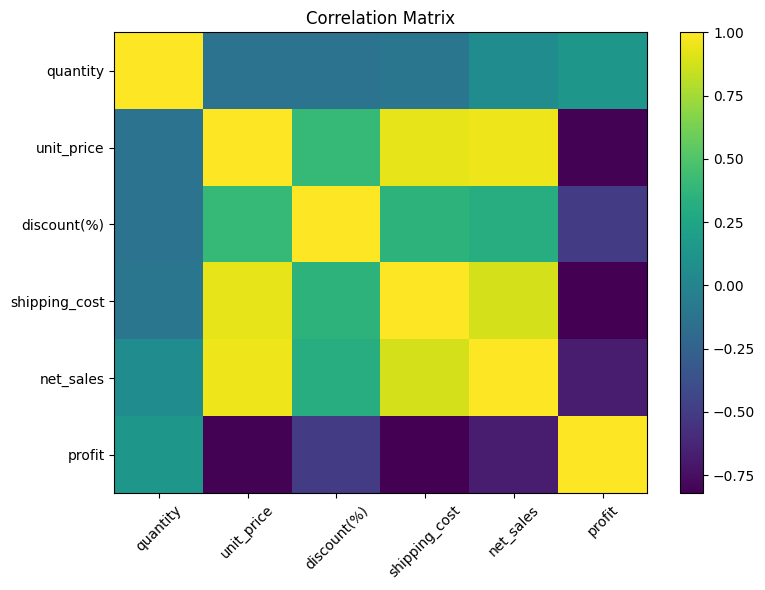

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix, aspect="auto")
plt.xticks(range(len(correlation_matrix.columns)),
           correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.columns)),
           correlation_matrix.columns)
plt.colorbar()
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## Explore distributions to assess data behaviour

### Numerical distributions

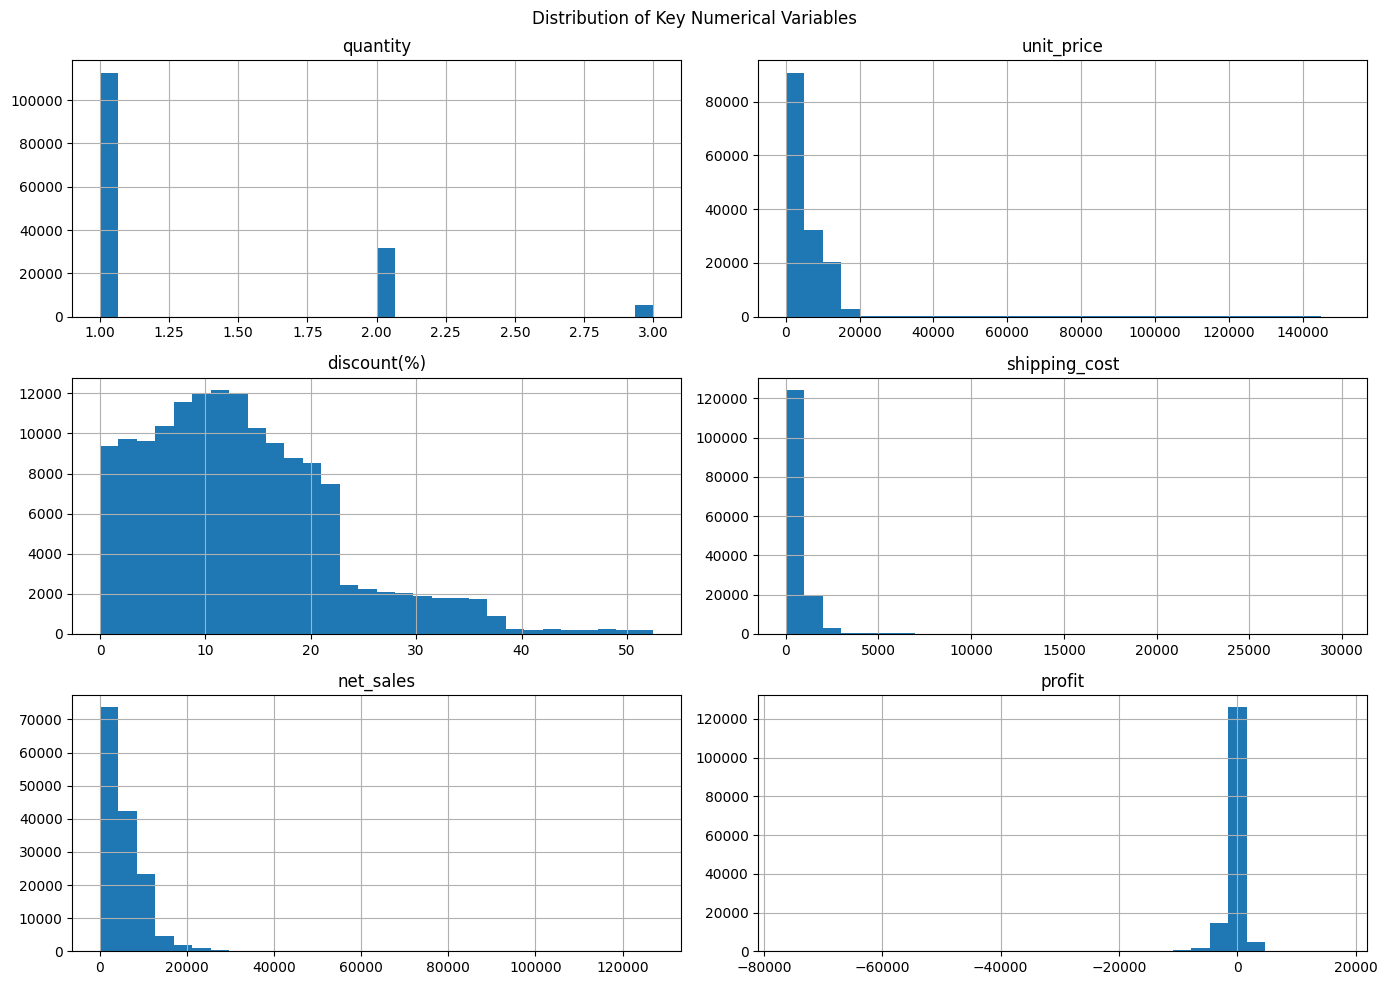

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = [
    "quantity",
    "unit_price",
    "discount(%)",
    "shipping_cost",
    "net_sales",
    "profit"
]

order_items_analysis[numeric_cols].hist(
    figsize=(14, 10),
    bins=30
)

plt.suptitle("Distribution of Key Numerical Variables")
plt.tight_layout()
plt.show()

### Distribution of Revenue

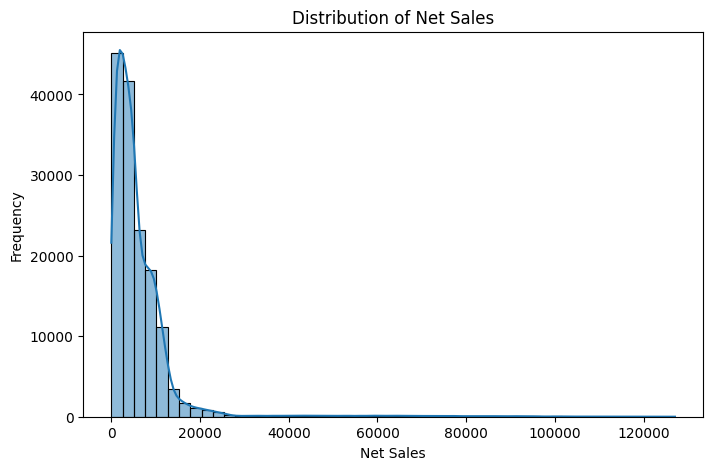

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    order_items_analysis["net_sales"],
    bins=50,
    kde=True
)

plt.title("Distribution of Net Sales")
plt.xlabel("Net Sales")
plt.ylabel("Frequency")
plt.show()

#### Narration:

Net sales are concentrated around lower values, with a long right tail indicating that a relatively small number of transactions generate substantially higher sales.

### Unit Price distribution

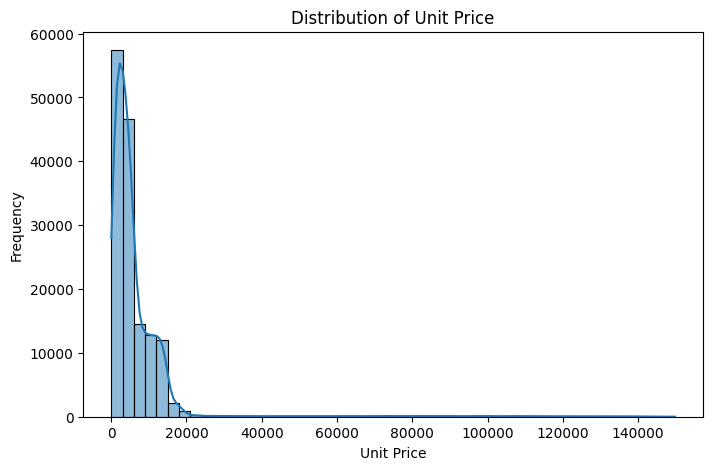

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    order_items_analysis["unit_price"],
    bins=50,
    kde=True
)

plt.title("Distribution of Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.show()

#### Insight:

Unit prices are strongly right-skewed, with most products concentrated at lower price levels and a smaller number of high-priced products.

### Quantity distribution

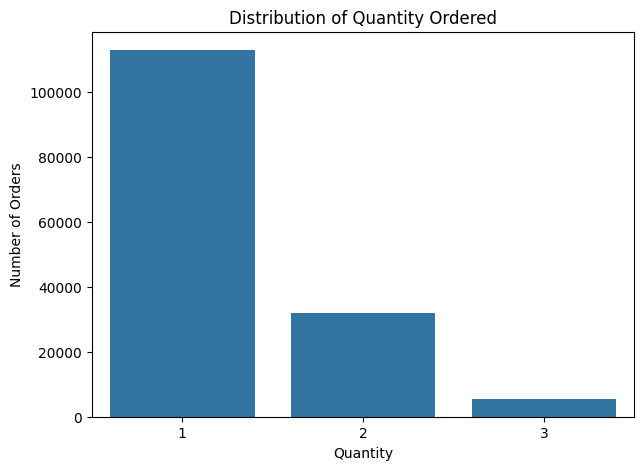

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=order_items_analysis,
    x="quantity"
)

plt.title("Distribution of Quantity Ordered")
plt.xlabel("Quantity")
plt.ylabel("Number of Orders")
plt.show()

#### Insight:

“Most transactions involve small quantities, while larger quantities occur less frequently.”

### Discount distribution

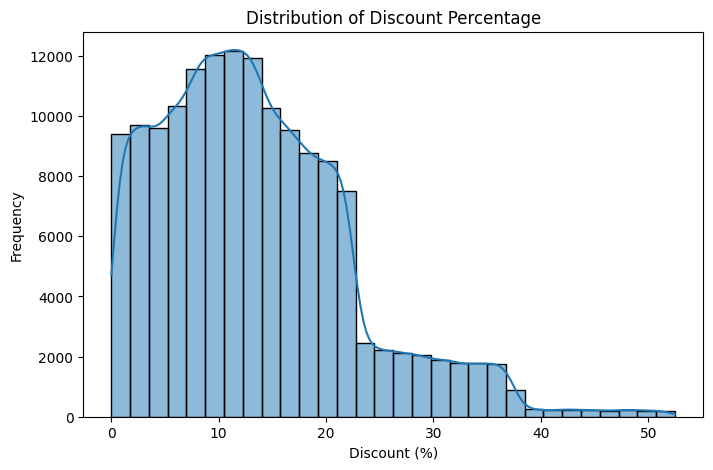

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    order_items_analysis["discount(%)"],
    bins=30,
    kde=True
)

plt.title("Distribution of Discount Percentage")
plt.xlabel("Discount (%)")
plt.ylabel("Frequency")
plt.show()

#### Narration:

“Discounts are concentrated within a relatively narrow range, while extreme discount values occur less frequently.”

### Profit distribution

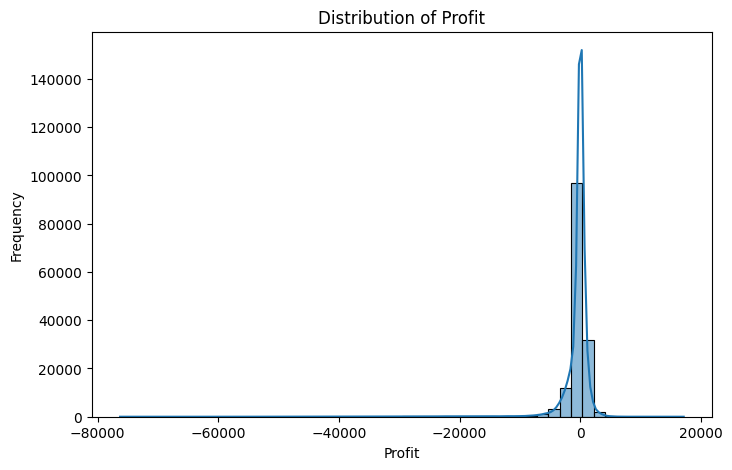

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    order_items_analysis["profit"],
    bins=50,
    kde=True
)

plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

## Categorical distributions

### Order status

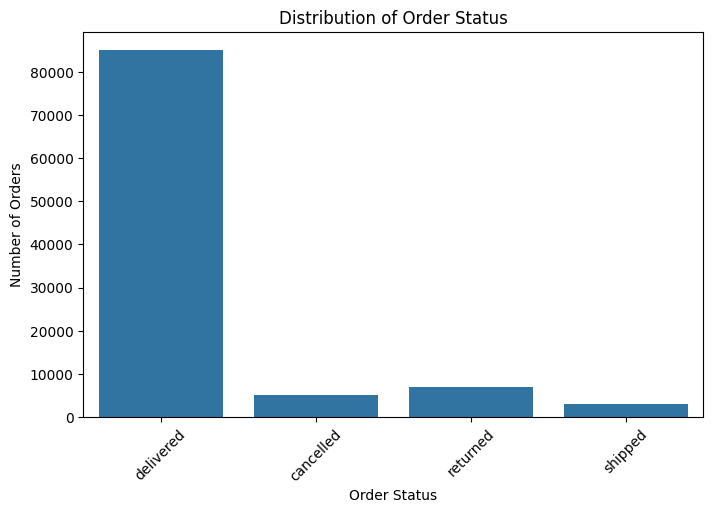

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=orders,
    x="order_status"
)

plt.title("Distribution of Order Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

### Payment type

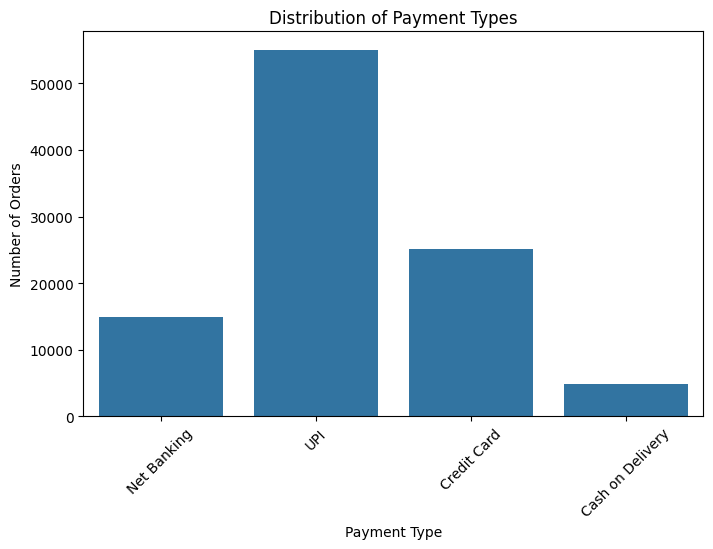

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=orders,
    x="payment_type"
)

plt.title("Distribution of Payment Types")
plt.xlabel("Payment Type")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

### Category distribution

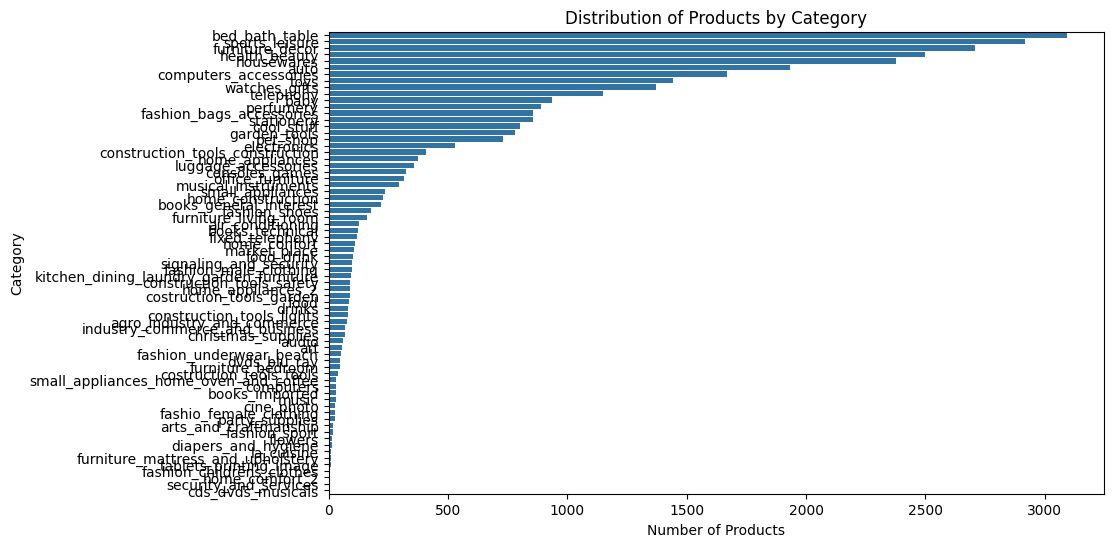

In [ ]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=products,
    y="Category_name",
    order=products["Category_name"].value_counts().index
)

plt.title("Distribution of Products by Category")
plt.xlabel("Number of Products")
plt.ylabel("Category")
plt.show()

## Identify early anomalies or unusual pattern

### Use boxplots to identify outliers

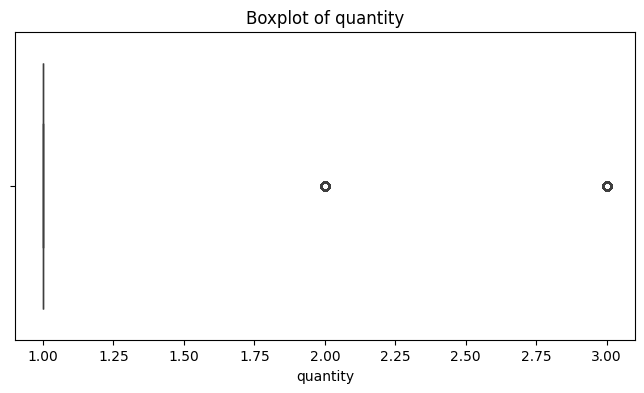

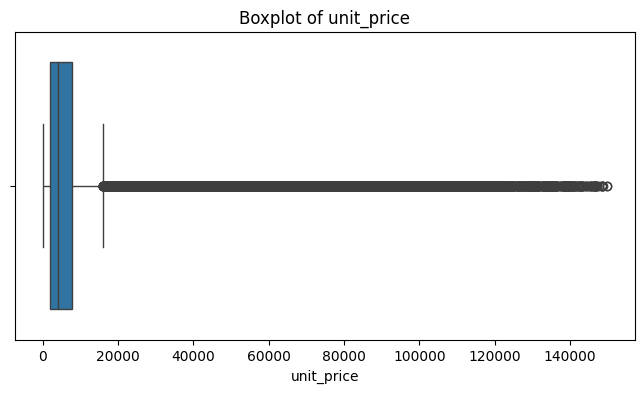

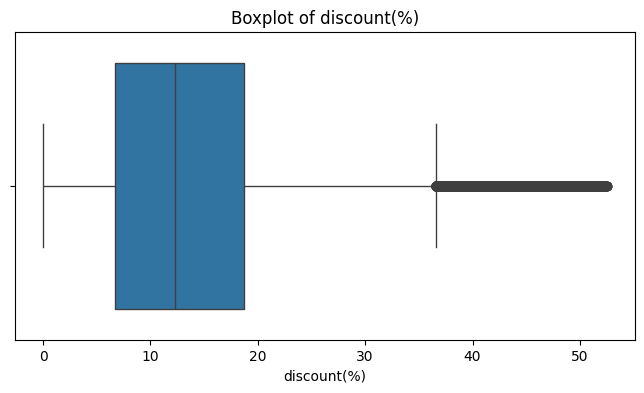

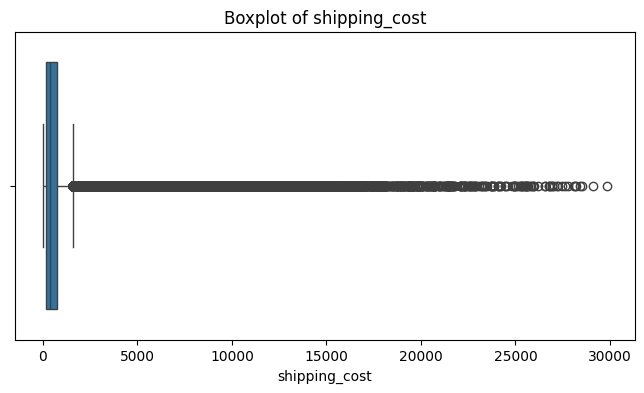

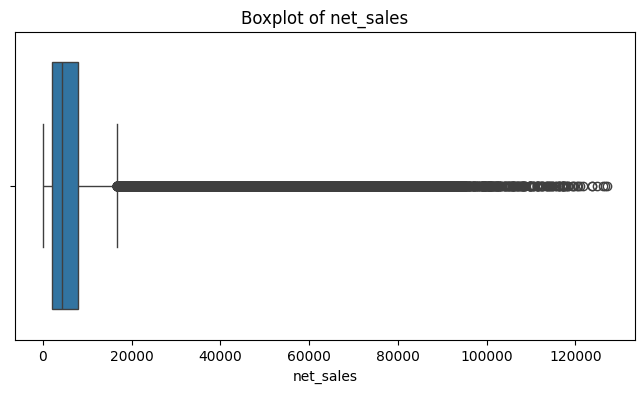

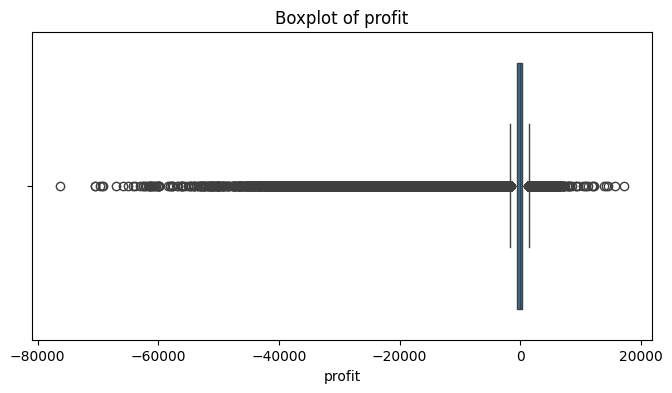

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = [
    "quantity",
    "unit_price",
    "discount(%)",
    "shipping_cost",
    "net_sales",
    "profit"
]

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=order_items_analysis[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

## Check unusual values numerically

In [ ]:
order_items_analysis["quantity"].describe()

count    150000.00000
mean          1.28356
std           0.52342
min           1.00000
25%           1.00000
50%           1.00000
75%           1.00000
max           3.00000
Name: quantity, dtype: float64

In [ ]:
order_items_analysis[
    order_items_analysis["quantity"] > 10
][["order_id", "product_id", "quantity"]].head(20)

,order_id,product_id,quantity


### Check unusual prices

In [ ]:
order_items_analysis[
    order_items_analysis["unit_price"] > 50000
][["product_id", "unit_price", "quantity"]].head(20)

,product_id,unit_price,quantity
71,P15672,52060.0,1
140,P26076,135540.0,1
154,P17623,96530.0,1
177,P26780,73790.0,1
191,P06320,100750.0,1
219,P19894,83090.0,1
256,P15031,90380.0,1
286,P26533,97730.0,1
312,P21371,114620.0,1
330,P03036,55920.0,1


### Check unusual discounts

In [ ]:
order_items_analysis[
    (order_items_analysis["discount(%)"] < 0) |
    (order_items_analysis["discount(%)"] > 50)
][
    ["order_id", "product_id", "unit_price", "discount(%)"]
].head(20)

,order_id,product_id,unit_price,discount(%)
286,O00132,P26533,97730.0,51.70
469,O00208,P04269,39000.0,50.45
2002,O00881,P02630,19270.0,51.32
2424,O01075,P20904,119270.0,51.34
3061,O01355,P14720,96660.0,51.50
3512,O01541,P24205,49900.0,50.75
4010,O01774,P10837,91080.0,52.42
4020,O01778,P13469,96360.0,50.93
4312,O01902,P24175,16320.0,52.11
5601,O02476,P03936,83770.0,51.65


### Check unusual shipping costs

In [ ]:
order_items_analysis[
    order_items_analysis["shipping_cost"] > 1000
][
    ["order_id", "product_id", "shipping_cost"]
].head(20)

,order_id,product_id,shipping_cost
1,O00002,P04408,1212.02
2,O00002,P14887,1478.39
16,O00009,P01978,1175.45
17,O00010,P21859,1771.67
22,O00013,P31979,1657.42
44,O00024,P16601,1001.35
46,O00024,P00496,1311.05
51,O00026,P00871,1288.38
52,O00027,P15258,2241.22
66,O00034,P21155,1533.03


### Check Unusual Profit

In [ ]:
order_items_analysis[
    order_items_analysis["profit"] < 0
][
    [
        "order_id",
        "product_id",
        "unit_price",
        "cost_price",
        "quantity",
        "net_sales",
        "shipping_cost",
        "profit"
    ]
].head(20)

,order_id,product_id,unit_price,cost_price,quantity,net_sales,shipping_cost,profit
1,O00002,P04408,7590.0,6190.0,1,6029.496,1212.02,-1372.524
2,O00002,P14887,14360.0,11720.0,2,21634.776,1478.39,-3283.614
3,O00003,P02014,1530.0,1300.0,2,2690.964,155.12,-64.156
4,O00003,P27255,1560.0,1300.0,1,1396.044,188.03,-91.986
9,O00005,P22006,3340.0,2940.0,2,6097.504,510.21,-292.706
16,O00009,P01978,11480.0,8830.0,1,9607.612,1175.45,-397.838
17,O00010,P21859,13590.0,11600.0,1,12478.338,1771.67,-893.332
19,O00011,P16354,3330.0,2890.0,1,3044.619,402.62,-248.001
22,O00013,P31979,13430.0,9970.0,1,11093.180,1657.42,-534.240
25,O00015,P28187,1180.0,1030.0,1,1157.580,142.02,-14.440


This identifies loss-making transactions.

Calculate how common they are:

In [ ]:
loss_making_pct = (
    (order_items_analysis["profit"] < 0).mean() * 100
)

print(f"Loss-making transactions: {loss_making_pct:.2f}%")

Loss-making transactions: 49.71%


### Check delivery anomalies

In [ ]:
orders[
    orders["delivery_days"] < 0
][
    [
        "order_id",
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "delivery_days"
    ]
]

,order_id,order_purchase_timestamp,order_delivered_customer_date,delivery_days


### check extremely long deliveries

In [ ]:
orders[
    orders["delivery_days"] > 60
][
    [
        "order_id",
        "delivery_days",
        "order_status"
    ]
].head(20)

,order_id,delivery_days,order_status
0,O00001,120.0,delivered
3,O00004,97.0,delivered
5,O00006,62.0,delivered
6,O00007,62.0,delivered
7,O00008,64.0,delivered
8,O00009,65.0,delivered
10,O00011,61.0,delivered
12,O00013,124.0,delivered
14,O00015,187.0,delivered
15,O00016,123.0,delivered


### Check unusual review scores

In [60]:
order_reviews = pd.read_csv("C:\\Anitha\\NIIT\\Capstone Project\\capstone-project-retail-tech\\Python\\cleaned_order_reviews.csv")

In [ ]:
order_reviews["review_score"].value_counts().sort_index()

review_score
1    11122
2     3035
3     8004
4    18608
5    56250
Name: count, dtype: int64

In [ ]:
order_reviews[
    (order_reviews["review_score"] < 1) |
    (order_reviews["review_score"] > 5)
]

,review_id,order_id,review_score,review_comment_message,review_date


### Look for unusual business patterns
##### High revenue + low quantity

In [ ]:
order_items_analysis[
    (order_items_analysis["net_sales"] > 50000) &
    (order_items_analysis["quantity"] <= 2)
]

,order_item_id,order_id,quantity,product_id,unit_price,discount(%),shipping_cost,cost_price,selling_price,Category_name,gross_sales,discount_amount,net_sales,total_cost,profit,profit_margin
140,OI000141,O00068,1,P26076,135540.0,35.83,17843.57,100630.0,135540.0,office_furniture,135540.0,48563.982,86976.018,100630.0,-31497.552,-36.214065
154,OI000155,O00075,1,P17623,96530.0,37.29,9214.83,64150.0,96530.0,home_appliances,96530.0,35996.037,60533.963,64150.0,-12830.867,-21.196146
191,OI000192,O00091,1,P06320,100750.0,36.10,6054.57,86150.0,100750.0,electronics,100750.0,36370.750,64379.250,86150.0,-27825.320,-43.220945
219,OI000220,O00104,1,P19894,83090.0,18.01,4846.93,69210.0,83090.0,computers_accessories,83090.0,14964.509,68125.491,69210.0,-5931.439,-8.706637
256,OI000257,O00120,1,P15031,90380.0,16.93,8575.69,69900.0,90380.0,furniture_decor,90380.0,15301.334,75078.666,69900.0,-3397.024,-4.524620
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149493,OI149494,O66285,1,P22980,88460.0,29.88,5230.29,73250.0,88460.0,furniture_decor,88460.0,26431.848,62028.152,73250.0,-16452.138,-26.523663
149503,OI149504,O66291,1,P03013,109480.0,18.53,6677.00,96750.0,109480.0,electronics,109480.0,20286.644,89193.356,96750.0,-14233.644,-15.958189
149680,OI149681,O66367,1,P23851,107140.0,35.74,15647.75,89370.0,107140.0,computers_accessories,107140.0,38291.836,68848.164,89370.0,-36169.586,-52.535295
149728,OI149729,O66389,1,P09110,63570.0,15.20,7172.48,58350.0,63570.0,computers_accessories,63570.0,9662.640,53907.360,58350.0,-11615.120,-21.546446


This could indicate high-value products.

##### High quantity + low revenue

In [ ]:
order_items_analysis[
    (order_items_analysis["quantity"] > 10) &
    (order_items_analysis["net_sales"] < 5000)
]

,order_item_id,order_id,quantity,product_id,unit_price,discount(%),shipping_cost,cost_price,selling_price,Category_name,gross_sales,discount_amount,net_sales,total_cost,profit,profit_margin


This could indicate low-priced bulk purchases.

### Anomaly summary

In [ ]:
anomaly_results = []

for col in cols:
    Q1 = order_items_analysis[col].quantile(0.25)
    Q3 = order_items_analysis[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (order_items_analysis[col] < lower_bound) |
        (order_items_analysis[col] > upper_bound)
    ).sum()

    anomaly_results.append({
        "Variable": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count
    })

anomaly_df = pd.DataFrame(anomaly_results)

anomaly_df

,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,quantity,1.00,1.00,0.00,1.00,1.00,37223
1,unit_price,2020.00,7640.00,5620.00,-6410.00,16070.00,5767
2,discount(%),6.73,18.67,11.94,-11.18,36.58,2775
3,shipping_cost,178.32,739.08,560.76,-662.82,1580.22,10996


## Pattern and trend analysis 

### Analyze correlations to uncover relationships

In [36]:
# Select numerical variables
corr_columns = [
    "cost_price",
    "selling_price",
    "unit_price",
    "quantity",
    "shipping_cost"
]

# Calculate correlation
correlation_matrix = order_items_analysis[corr_columns].corr()

print(correlation_matrix.round(2))

               cost_price  selling_price  unit_price  quantity  shipping_cost
cost_price           1.00           0.99        0.99     -0.13           0.93
selling_price        0.99           1.00        1.00     -0.12           0.94
unit_price           0.99           1.00        1.00     -0.12           0.94
quantity            -0.13          -0.12       -0.12      1.00          -0.11
shipping_cost        0.93           0.94        0.94     -0.11           1.00


In [62]:
# Merge Order Items with Reviews
order_items_analysis = order_items_analysis.merge(
    order_reviews[["order_id","review_score"]],
    on="order_id",
    how="left"
)

In [63]:
correlations = {
    "Cost Price vs Selling Price":
        order_items_analysis["cost_price"].corr(order_items_analysis["selling_price"]),

    "Unit Price vs Selling Price":
        order_items_analysis["unit_price"].corr(order_items_analysis["selling_price"]),

    "Unit Price vs Revenue":
        order_items_analysis["unit_price"].corr(order_items_analysis["net_sales"]),

    "Quantity vs Shipping Cost":
        order_items_analysis["quantity"].corr(order_items_analysis["shipping_cost"]),

    "Review Score vs Revenue":
        order_items_analysis["review_score"].corr(order_items_analysis["net_sales"])
}

for relationship, value in correlations.items():
    print(f"{relationship}: {value:.2f}")

Cost Price vs Selling Price: 0.99
Unit Price vs Selling Price: 1.00
Unit Price vs Revenue: 0.95
Quantity vs Shipping Cost: -0.11
Review Score vs Revenue: -0.00


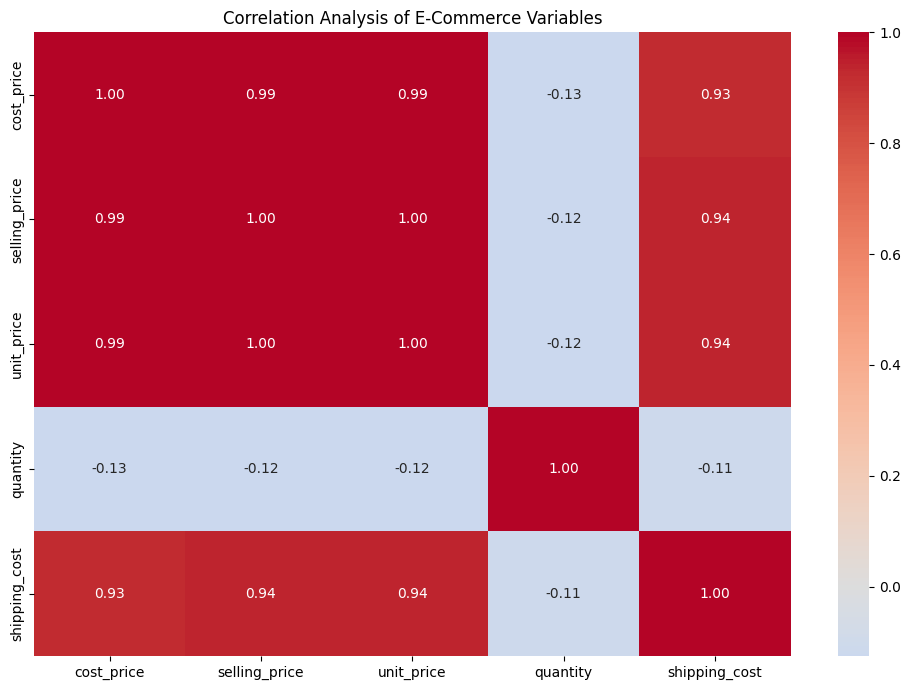

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Analysis of E-Commerce Variables")
plt.tight_layout()
plt.show()

## Revenue Trend Over Time

In [67]:
order_items_analysis = order_items_analysis.merge(
    orders[["order_id","order_purchase_timestamp"]],
    on="order_id",
    how="left")

In [70]:
# Monthly revenue
monthly_revenue = (
    order_items_analysis
    .set_index("order_purchase_timestamp")
    .resample("ME")["net_sales"]
    .sum()
)

print(monthly_revenue)

order_purchase_timestamp
2021-04-30    1.135895e+07
2021-05-31    1.223809e+07
2021-06-30    1.111914e+07
2021-07-31    1.256500e+07
2021-08-31    1.901287e+07
2021-09-30    1.412775e+07
2021-10-31    3.059767e+07
2021-11-30    2.590413e+07
2021-12-31    1.771847e+07
2022-01-31    1.817884e+07
2022-02-28    1.191470e+07
2022-03-31    1.217640e+07
2022-04-30    1.296674e+07
2022-05-31    1.352025e+07
2022-06-30    1.339397e+07
2022-07-31    1.411699e+07
2022-08-31    1.886969e+07
2022-09-30    1.477400e+07
2022-10-31    3.101409e+07
2022-11-30    2.817093e+07
2022-12-31    1.936456e+07
2023-01-31    1.811331e+07
2023-02-28    1.234345e+07
2023-03-31    1.245941e+07
2023-04-30    1.363023e+07
2023-05-31    1.371558e+07
2023-06-30    1.271313e+07
2023-07-31    1.577273e+07
2023-08-31    2.103382e+07
2023-09-30    1.654260e+07
2023-10-31    3.258632e+07
2023-11-30    2.850889e+07
2023-12-31    1.979142e+07
2024-01-31    2.025513e+07
2024-02-29    1.238324e+07
2024-03-31    1.337093e+07
202

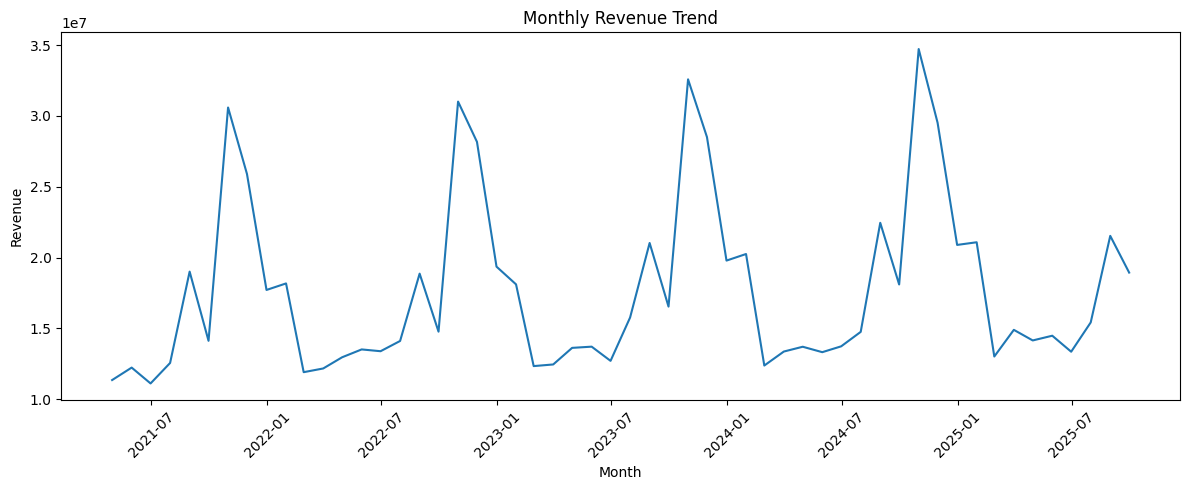

In [71]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_revenue.index, monthly_revenue.values)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Yearly Trend

In [73]:
order_items_analysis["year"] = (
    order_items_analysis["order_purchase_timestamp"].dt.year
)

yearly_revenue = (
    order_items_analysis.groupby("year")["net_sales"]
    .sum()
)

print(yearly_revenue)

year
2021    1.546421e+08
2022    2.084612e+08
2023    2.172109e+08
2024    2.272460e+08
2025    1.469138e+08
Name: net_sales, dtype: float64


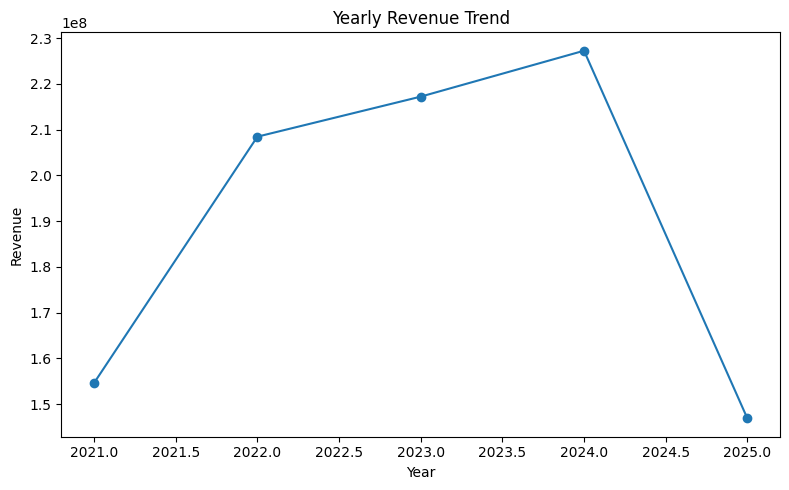

In [74]:
plt.figure(figsize=(8, 5))

plt.plot(
    yearly_revenue.index,
    yearly_revenue.values,
    marker="o"
)

plt.title("Yearly Revenue Trend")
plt.xlabel("Year")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

### Category trend

In [75]:
category_revenue = (
    order_items_analysis.groupby("Category_name")["net_sales"]
    .sum()
    .sort_values(ascending=False)
)

print(category_revenue)

Category_name
furniture_decor              8.873177e+07
bed_bath_table               8.814738e+07
sports_leisure               8.497692e+07
health_beauty                7.068280e+07
housewares                   6.857588e+07
                                 ...     
la_cuisine                   3.206088e+05
diapers_and_hygiene          2.165633e+05
fashion_childrens_clothes    1.150893e+05
cds_dvds_musicals            7.778324e+04
security_and_services        4.198737e+04
Name: net_sales, Length: 71, dtype: float64


### Customer segment trend

In [88]:
order_items_analysis = order_items_analysis.merge(
    orders[["order_id","customer_id"]],
    on="order_id",
    how="left"
)

In [89]:
order_items_analysis = order_items_analysis.merge(
    customers[["customer_id", "customer_segment"]],
    on="customer_id",
    how="left"
)

In [90]:
segment_revenue = (
    order_items_analysis.groupby("customer_segment")["net_sales"]
    .sum()
    .sort_values(ascending=False)
)

print(segment_revenue)

customer_segment
New          4.827704e+08
Returning    3.328513e+08
Loyal        1.388521e+08
Name: net_sales, dtype: float64


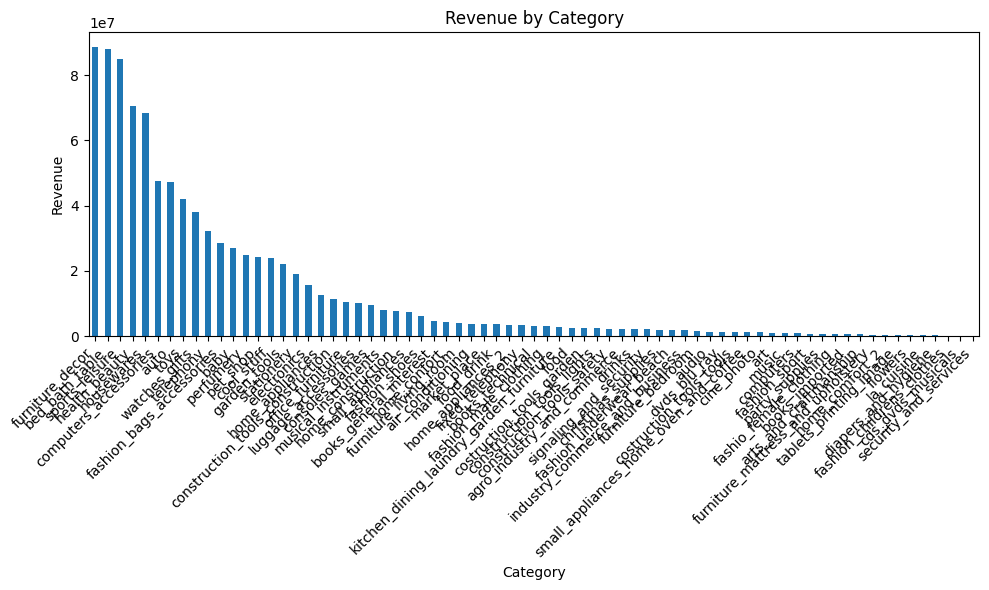

In [99]:
plt.figure(figsize=(10, 6))

category_revenue.plot(kind="bar")

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

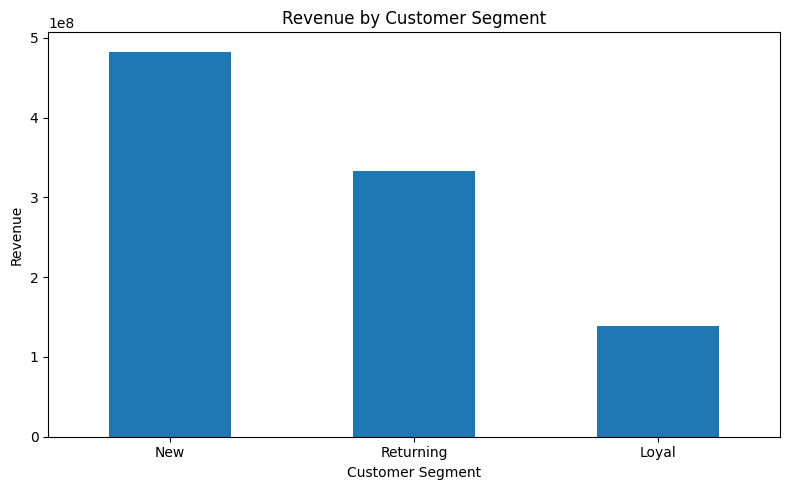

In [100]:
plt.figure(figsize=(8, 5))

segment_revenue.plot(kind="bar")

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Examine group-level behaviours for insights

### Customer segment behaviour

In [102]:
segment_behavior = (
    order_items_analysis
    .groupby("customer_segment")
    .agg(
        Total_Revenue=("net_sales", "sum"),
        Total_Quantity=("quantity", "sum"),
        Total_Orders=("order_id", "nunique")
    )
    .reset_index()
)

print(segment_behavior)

  customer_segment  Total_Revenue  Total_Quantity  Total_Orders
0            Loyal   1.388521e+08           28355          9763
1              New   4.827704e+08           96352         33455
2        Returning   3.328513e+08           67827         23299


### Average Order Value by customer segment

In [103]:
segment_behavior["Average_Order_Value"] = (
    segment_behavior["Total_Revenue"] /
    segment_behavior["Total_Orders"]
)

print(segment_behavior)

  customer_segment  Total_Revenue  Total_Quantity  Total_Orders  \
0            Loyal   1.388521e+08           28355          9763   
1              New   4.827704e+08           96352         33455   
2        Returning   3.328513e+08           67827         23299   

   Average_Order_Value  
0         14222.281848  
1         14430.442262  
2         14286.077668  


### Plot customer segment behaviour

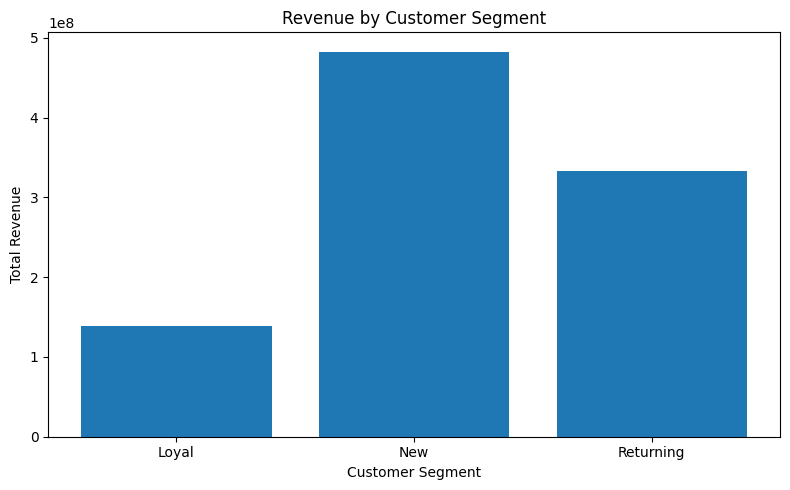

In [104]:
plt.figure(figsize=(8, 5))

plt.bar(
    segment_behavior["customer_segment"],
    segment_behavior["Total_Revenue"]
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue")

plt.tight_layout()
plt.show()

Group-level analysis shows differences in purchasing behaviour across customer segments. New customers contribute significantly to revenue, while loyal customers contribute comparatively less, indicating an opportunity to investigate and improve spending among existing customers.

### Examine category-level behaviour

In [105]:
category_behavior = (
    order_items_analysis
    .groupby("Category_name")
    .agg(
        Total_Revenue=("net_sales", "sum"),
        Total_Quantity=("quantity", "sum"),
        Total_Orders=("order_id", "nunique"),
        Average_Unit_Price=("unit_price", "mean")
    )
    .reset_index()
    .sort_values("Total_Revenue", ascending=False)
)

print(category_behavior)

                Category_name  Total_Revenue  Total_Quantity  Total_Orders  \
39            furniture_decor   8.873177e+07            3476          2989   
7              bed_bath_table   8.814738e+07           18969         13659   
65             sports_leisure   8.497692e+07           18186         13094   
43              health_beauty   7.068280e+07           15000         11029   
49                 housewares   6.857588e+07           14627         10845   
..                        ...            ...             ...           ...   
52                 la_cuisine   3.206088e+05              58            49   
23        diapers_and_hygiene   2.165633e+05              57            44   
29  fashion_childrens_clothes   1.150893e+05              72            57   
11          cds_dvds_musicals   7.778324e+04               7             5   
61      security_and_services   4.198737e+04               7             6   

    Average_Unit_Price  
39        40944.452579  
7          59

### Payment Type

In [108]:
order_items_analysis = order_items_analysis.merge(
    orders[["order_id", "payment_type"]],
    on = "order_id",
    how = "left"
)

In [109]:
payment_analysis = (
    order_items_analysis
    .groupby("payment_type")
    .agg(
        Revenue=("net_sales", "sum"),
        Orders=("order_id", "nunique"),
        Quantity=("quantity", "sum")
    )
    .reset_index()
)

payment_analysis["AOV"] = (
    payment_analysis["Revenue"] /
    payment_analysis["Orders"]
)

print(payment_analysis)

       payment_type       Revenue  Orders  Quantity           AOV
0  Cash on Delivery  4.775060e+07    3338      9622  14305.154174
1       Credit Card  2.365576e+08   16577     48164  14270.230162
2       Net Banking  1.416692e+08    9935     28687  14259.609142
3               UPI  5.284965e+08   36667    106061  14413.409340


### Brand

In [112]:
order_items_analysis = order_items_analysis.merge(
    products[["product_id", "brand"]],
    on = "product_id",
    how = "left"
)

In [113]:
brand_analysis = (
    order_items_analysis
    .groupby("brand")
    .agg(
        Revenue=("net_sales", "sum"),
        Orders=("order_id", "nunique"),
        Quantity=("quantity", "sum")
    )
    .reset_index()
    .sort_values("Revenue", ascending=False)
)

print(brand_analysis.head(10))

                brand       Revenue  Orders  Quantity
19     Generic Indian  4.935550e+08   51661    105778
18     Generic Global  8.431249e+07   13084     18126
51       Urban Ladder  2.494991e+07     836       959
45          Pepperfry  2.352552e+07     782       898
40           Nilkamal  2.317111e+07     871       994
14             Durian  2.270345e+07     703       810
25               IKEA  2.211030e+07     668       754
20     Godrej Interio  2.105790e+07     800       955
24  Himalaya Pet Care  1.067400e+07    2222      2958
2              Amaron  1.033644e+07    1636      2082


### Age Group

In [114]:
order_items_analysis = order_items_analysis.merge(
    customers[["customer_id", "age_group"]],
    on = "customer_id",
    how = "left"
)

In [115]:
age_analysis = (
    order_items_analysis
    .groupby("age_group")
    .agg(
        Revenue=("net_sales", "sum"),
        Orders=("order_id", "nunique"),
        Quantity=("quantity", "sum")
    )
    .reset_index()
)

age_analysis["AOV"] = (
    age_analysis["Revenue"] /
    age_analysis["Orders"]
)

print(age_analysis)

  age_group       Revenue  Orders  Quantity           AOV
0     18-25  1.153931e+08    8005     22838  14415.131257
1     26-35  2.265305e+08   15941     46450  14210.558561
2     36-45  3.441313e+08   23962     69274  14361.545004
3     46-55  1.719400e+08   12007     34859  14319.976865
4     56-65  6.781198e+07    4641     13498  14611.501407
5       65+  2.866699e+07    1961      5615  14618.554696


### Gender

In [116]:
order_items_analysis = order_items_analysis.merge(
    customers[["customer_id", "gender"]],
    on = "customer_id",
    how = "left"
)

In [117]:
gender_analysis = (
    order_items_analysis
    .groupby("gender")
    .agg(
        Revenue=("net_sales", "sum"),
        Orders=("order_id", "nunique"),
        Quantity=("quantity", "sum")
    )
    .reset_index()
)

gender_analysis["AOV"] = (
    gender_analysis["Revenue"] /
    gender_analysis["Orders"]
)

print(gender_analysis)

   gender       Revenue  Orders  Quantity           AOV
0  Female  3.196021e+08   22386     64559  14276.874410
1    Male  6.348718e+08   44131    127975  14386.073204


In [118]:
order_items_analysis = order_items_analysis.merge(
    customers[["customer_id", "customer_zip_code"]],
    on="customer_id",
    how="left"
)

In [119]:
geolocation = pd.read_csv("C:\\Anitha\\NIIT\\Capstone Project\\capstone-project-retail-tech\\Python\\cleaned_geolocation.csv")

In [120]:
order_items_analysis = order_items_analysis.merge(
    geolocation[[
        "geolocation_zip_code",
        "region"
    ]],
    left_on="customer_zip_code",
    right_on="geolocation_zip_code",
    how="left"
)

### Region-wise behaviour

In [122]:
region_behavior = (
    order_items_analysis
    .groupby("region")
    .agg(
        Total_Revenue=("net_sales", "sum"),
        Total_Orders=("order_id", "nunique"),
        Total_Quantity=("quantity", "sum")
    )
    .reset_index()
)

region_behavior["AOV"] = (
    region_behavior["Total_Revenue"] /
    region_behavior["Total_Orders"]
)

region_behavior = region_behavior.sort_values(
    "Total_Revenue",
    ascending=False
)

print(region_behavior)

      region  Total_Revenue  Total_Orders  Total_Quantity            AOV
2      North   3.671292e+09         18122          739181  202587.568598
4      South   2.549515e+09         18426          514241  138365.074344
1       East   2.438977e+09         12493          492992  195227.520582
5       West   1.881961e+09          9485          370733  198414.492290
0    Central   1.079382e+09          4939          219072  218542.705256
3  Northeast   5.260757e+08          3052          108758  172370.796312


### Region-wise Revenue

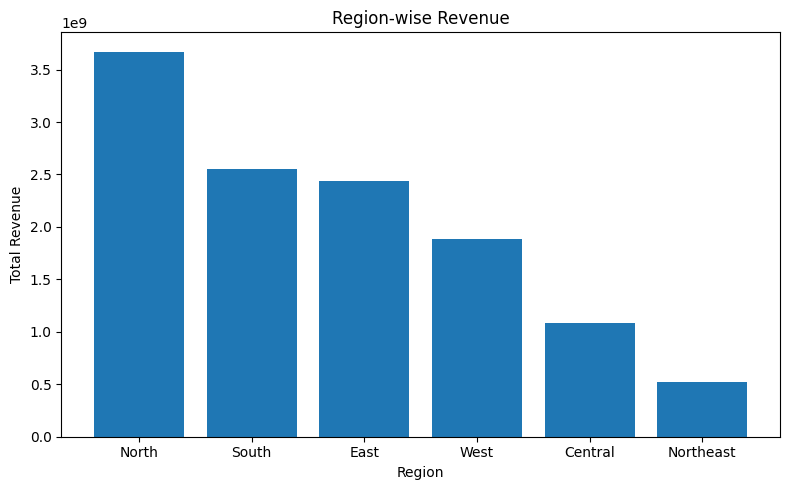

In [123]:
plt.figure(figsize=(8, 5))

plt.bar(
    region_behavior["region"],
    region_behavior["Total_Revenue"]
)

plt.title("Region-wise Revenue")
plt.xlabel("Region")
plt.ylabel("Total Revenue")

plt.tight_layout()
plt.show()

### Region-wise Orders

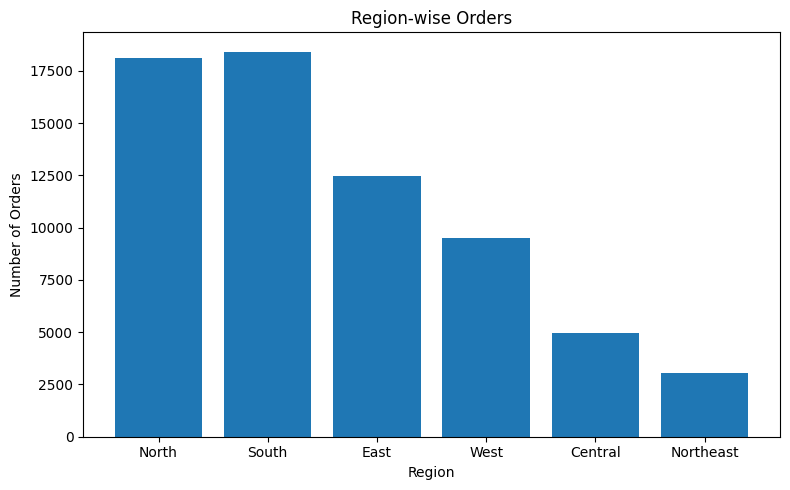

In [124]:
plt.figure(figsize=(8, 5))

plt.bar(
    region_behavior["region"],
    region_behavior["Total_Orders"]
)

plt.title("Region-wise Orders")
plt.xlabel("Region")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

### Overall Interpretation

Group-level analysis revealed clear differences in purchasing behaviour across customer segments, product categories, and regions. Furniture emerged as a major revenue-generating category, while customer segments differed in their contribution to revenue and order volume. Regional analysis also showed variations in sales performance, indicating that customer purchasing behaviour is not uniform across locations. These differences help identify high-performing groups and areas with potential for improvement, providing direction for targeted marketing, product strategies, and customer engagement.

# Visual Exploration 

## Create scatter plots to study relationships

### Unit Price vs Revenue

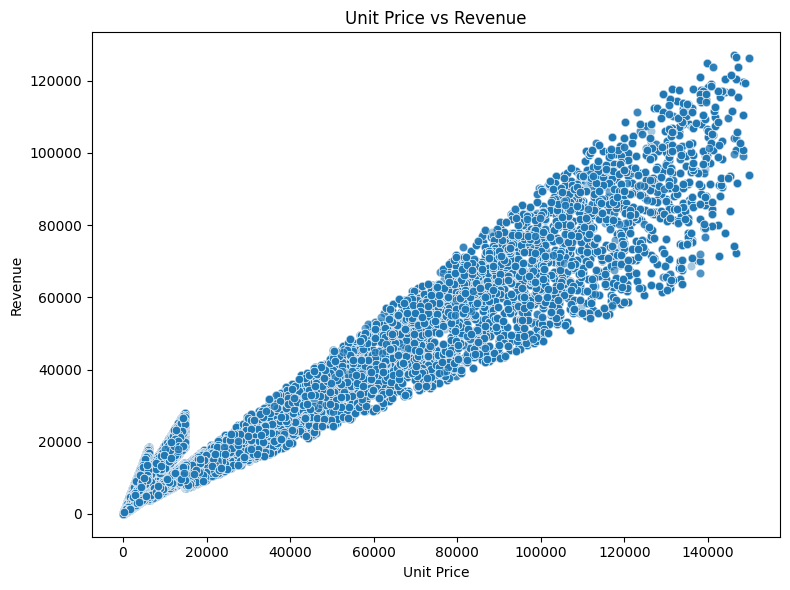

In [126]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=order_items_analysis,
    x="unit_price",
    y="net_sales",
    alpha=0.4
)

plt.title("Unit Price vs Revenue")
plt.xlabel("Unit Price")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

### Cost Price vs Selling Price

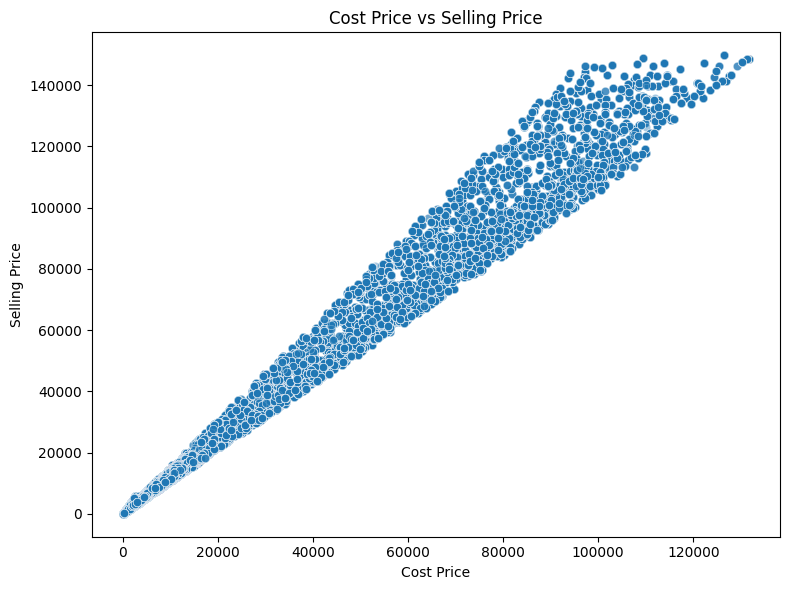

In [127]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=order_items_analysis,
    x="cost_price",
    y="selling_price",
    alpha=0.4
)

plt.title("Cost Price vs Selling Price")
plt.xlabel("Cost Price")
plt.ylabel("Selling Price")

plt.tight_layout()
plt.show()

### Quantity vs Shipping Cost

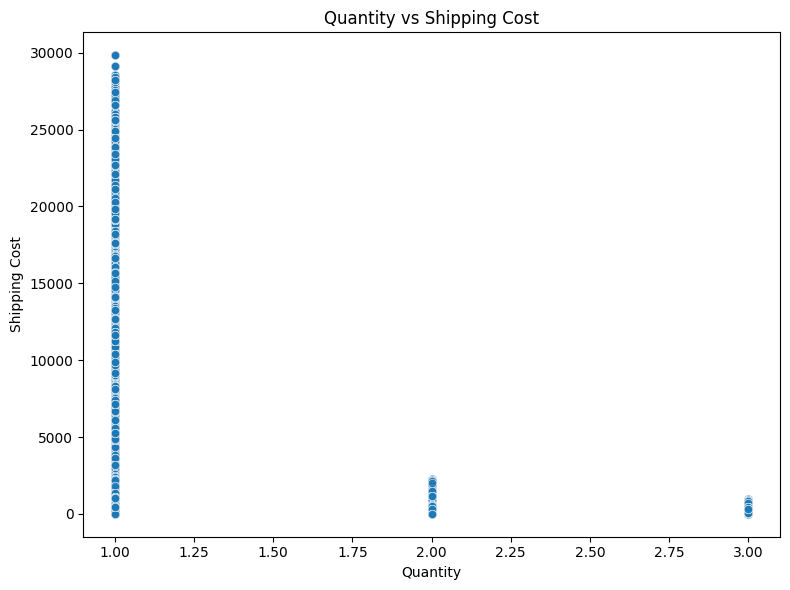

In [128]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=order_items_analysis,
    x="quantity",
    y="shipping_cost",
    alpha=0.4
)

plt.title("Quantity vs Shipping Cost")
plt.xlabel("Quantity")
plt.ylabel("Shipping Cost")

plt.tight_layout()
plt.show()

### Review Score vs Revenue

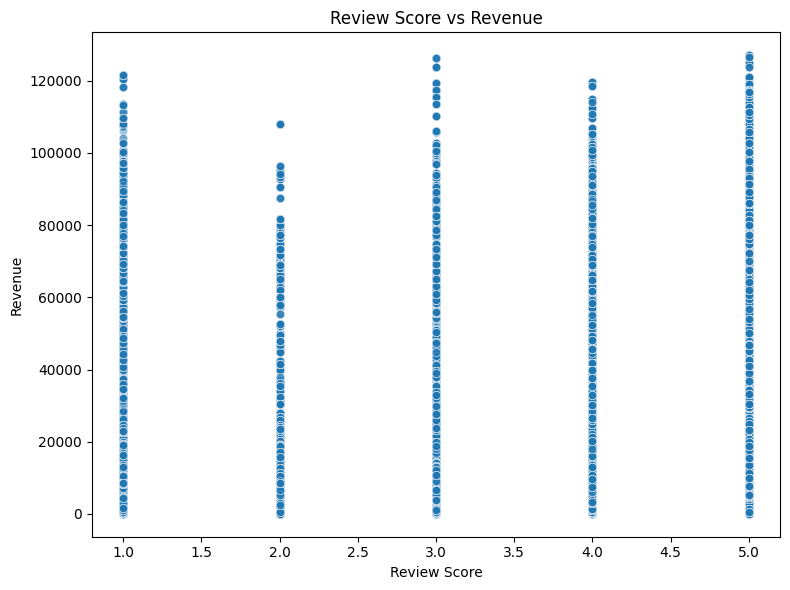

In [130]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=order_items_analysis,
    x="review_score",
    y="net_sales",
    alpha=0.4
)

plt.title("Review Score vs Revenue")
plt.xlabel("Review Score")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

#### Interpretation:
Scatter plot analysis visually confirmed the correlation results. Unit price and revenue showed a strong positive relationship, while cost price and selling price showed a very strong positive relationship. Quantity and shipping cost displayed a weak relationship, whereas review score and revenue showed no clear linear pattern.

## Use heatmaps to highlight correlations

### Create the correlation matrix

In [131]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
correlation_columns = [
    "cost_price",
    "selling_price",
    "unit_price",
    "quantity",
    "shipping_cost",
    "review_score",
    "net_sales"
]

correlation_matrix = (
    order_items_analysis[correlation_columns]
    .corr()
)

print(correlation_matrix.round(2))

               cost_price  selling_price  unit_price  quantity  shipping_cost  \
cost_price           1.00           0.99        0.99     -0.13           0.93   
selling_price        0.99           1.00        1.00     -0.12           0.93   
unit_price           0.99           1.00        1.00     -0.12           0.93   
quantity            -0.13          -0.12       -0.12      1.00          -0.11   
shipping_cost        0.93           0.93        0.93     -0.11           1.00   
review_score        -0.00          -0.00       -0.00      0.00          -0.00   
net_sales            0.95           0.95        0.95      0.06           0.88   

               review_score  net_sales  
cost_price             -0.0       0.95  
selling_price          -0.0       0.95  
unit_price             -0.0       0.95  
quantity                0.0       0.06  
shipping_cost          -0.0       0.88  
review_score            1.0      -0.00  
net_sales              -0.0       1.00  


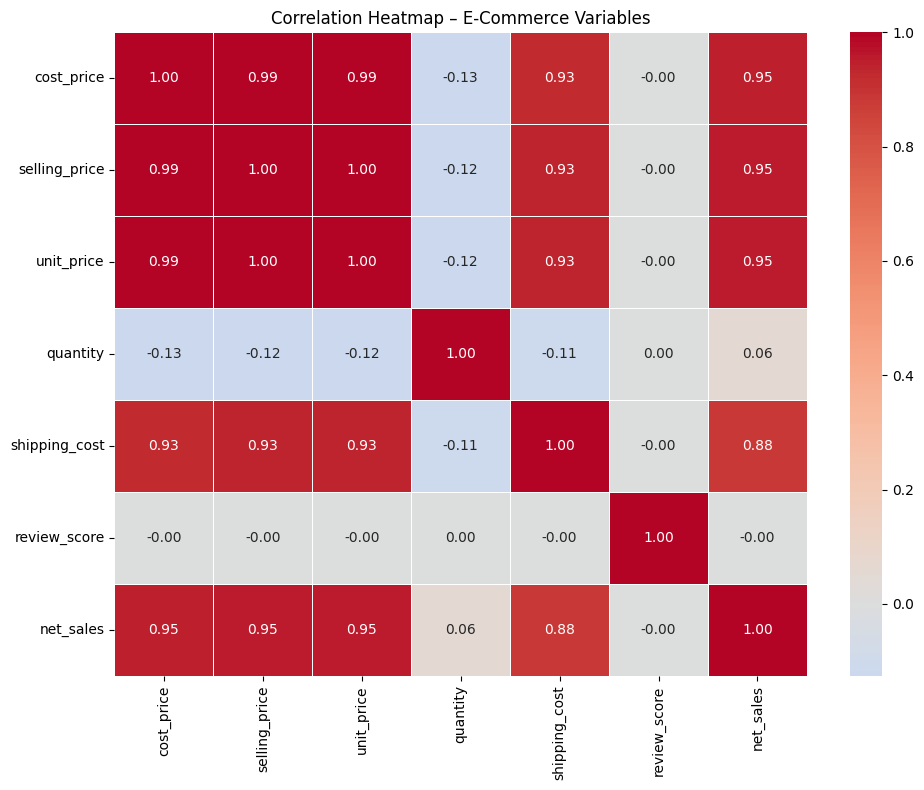

In [132]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap – E-Commerce Variables")
plt.tight_layout()
plt.show()

# Insight Interpretation
## Identify key signals influencing outcomes

| Key signal           | Finding                                             | Possible influence on outcome                          |
| -------------------- | --------------------------------------------------- | ------------------------------------------------------ |
| **Unit Price**       | Strong correlation with revenue (**0.95**)          | Higher-priced items contribute strongly to revenue     |
| **Selling Price**    | Very strong relationship with cost price (**0.99**) | Product pricing is closely linked to product cost      |
| **Product Category** | Furniture is a leading revenue category             | Category mix strongly affects overall revenue          |
| **Customer Segment** | Revenue differs between customer groups             | Customer type influences sales contribution            |
| **Region**           | Sales performance varies by region                  | Location influences purchasing activity                |
| **Payment Type**     | UPI is frequently used                              | Payment preference can influence transaction behaviour |
| **Review Score**     | Almost no correlation with revenue (**0.00**)       | Ratings alone do not appear to drive revenue           |
| **Quantity**         | Weak relationship with shipping cost (**-0.11**)    | Quantity has little influence on shipping cost         |


In [135]:
# Get correlation with revenue
revenue_correlation = (
    correlation_matrix["net_sales"]
    .drop("net_sales")
    .sort_values(key=abs, ascending=False)
)

print("Variables most strongly associated with Revenue:")
print(revenue_correlation.round(2))

Variables most strongly associated with Revenue:
selling_price    0.95
unit_price       0.95
cost_price       0.95
shipping_cost    0.88
quantity         0.06
review_score    -0.00
Name: net_sales, dtype: float64


## Overall interpretation 

The analysis identified product pricing, product category, customer segment, and region as important signals associated with sales performance. Unit price showed a strong positive relationship with revenue, indicating that pricing has a major influence on revenue generation. Furniture was identified as a leading revenue-generating category, while differences across customer segments and regions indicate variations in purchasing behaviour. In contrast, review scores showed almost no relationship with revenue, suggesting that customer ratings alone are not a strong signal of revenue performance. These findings provide direction for further analysis of pricing, product mix, customer targeting, and regional sales strategies.

## spot anomalies affecting hypothesis direction
### Check whether anomalies affect your revenue relationship

In [140]:
# Variables to check for anomalies
numeric_columns = [
    "quantity",
    "unit_price",
    "shipping_cost",
    "net_sales",
    "review_score",
    "cost_price",
    "selling_price"
]

# Original correlations
original_correlations = {
    "Unit Price vs Revenue":
        order_items_analysis["unit_price"].corr(
            order_items_analysis["net_sales"]
        ),

    "Cost Price vs Selling Price":
        order_items_analysis["cost_price"].corr(
            order_items_analysis["selling_price"]
        ),

    "Quantity vs Revenue":
        order_items_analysis["quantity"].corr(
            order_items_analysis["net_sales"]
        ),

    "Review Score vs Revenue":
        order_items_analysis["review_score"].corr(
            order_items_analysis["net_sales"]
        )
}

# Remove outliers from all selected variables
filtered_data = order_items_analysis.copy()

for column in numeric_columns:

    Q1 = filtered_data[column].quantile(0.25)
    Q3 = filtered_data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    filtered_data = filtered_data[
        filtered_data[column].between(
            lower_bound,
            upper_bound
        )
    ]

# Correlations after removing outliers
filtered_correlations = {
    "Unit Price vs Revenue":
        filtered_data["unit_price"].corr(
            filtered_data["net_sales"]
        ),

    "Cost Price vs Selling Price":
        filtered_data["cost_price"].corr(
            filtered_data["selling_price"]
        ),

    "Quantity vs Revenue":
        filtered_data["quantity"].corr(
            filtered_data["net_sales"]
        ),

    "Review Score vs Revenue":
        filtered_data["review_score"].corr(
            filtered_data["net_sales"]
        )
}

# Create comparison table
correlation_comparison = pd.DataFrame({
    "Relationship": original_correlations.keys(),
    "Before_Outlier_Removal": original_correlations.values(),
    "After_Outlier_Removal": filtered_correlations.values()
})

correlation_comparison["Change"] = (
    correlation_comparison["After_Outlier_Removal"] -
    correlation_comparison["Before_Outlier_Removal"]
)

print(correlation_comparison.round(2))

                  Relationship  Before_Outlier_Removal  After_Outlier_Removal  \
0        Unit Price vs Revenue                    0.95                   0.98   
1  Cost Price vs Selling Price                    0.99                   0.99   
2          Quantity vs Revenue                    0.06                    NaN   
3      Review Score vs Revenue                   -0.00                   0.01   

   Change  
0    0.03  
1   -0.01  
2     NaN  
3    0.01  


c:\Users\Anitha R\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Anitha R\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Anomaly analysis identified extreme observations in quantity, unit price, shipping cost, revenue, and review score. These anomalies were examined because unusually high or low values can influence correlations and potentially alter the direction of hypotheses. Comparing relationships before and after outlier treatment helps determine whether observed patterns are robust or driven by extreme observations.

## Connect visual findings to business meaning

### 1. Unit Price vs Revenue — Scatter Plot

**Visual finding:** Strong positive relationship between unit price and revenue (correlation ≈ **0.95**).

**Business meaning:**

> Higher-priced products contribute substantially to revenue. The business should identify high-value products and evaluate opportunities for premium pricing, while ensuring that pricing remains competitive.

---

### 2. Cost Price vs Selling Price — Scatter Plot

**Visual finding:** Very strong positive relationship (correlation ≈ **0.99**).

**Business meaning:**

> Selling prices closely follow product costs, indicating that product cost is a major factor in pricing decisions. Monitoring cost changes can help maintain appropriate profit margins.

---

### 3. Category Revenue — Bar Chart

**Visual finding:** **Furniture** is one of the strongest revenue-generating categories.

**Business meaning:**

> Strong performance in Furniture suggests an opportunity to prioritize inventory, promotions, and marketing for high-performing product categories while investigating ways to improve weaker categories.

---

### 4. Customer Segment — Bar Chart

**Visual finding:** Revenue contribution differs across customer segments, with **new customers generating relatively high revenue** compared with some existing segments.

**Business meaning:**

> Strong spending from new customers indicates effective initial customer acquisition. The business should focus on retention strategies and increasing repeat purchases so that high-value customers continue contributing revenue over time.

---

### 5. Region-wise Revenue — Bar Chart

**Visual finding:** Revenue varies across regions.

**Business meaning:**

> Regional differences indicate that customer demand is not uniform geographically. High-performing regions can be prioritized for expansion, while lower-performing regions may require targeted promotions or investigation into customer preferences.

---

### 6. Review Score vs Revenue — Scatter Plot

**Visual finding:** Almost no correlation between review score and revenue (**≈ 0.00**).

**Business meaning:**

> Customer ratings alone do not appear to be a strong driver of revenue. Therefore, revenue improvement efforts should also consider factors such as pricing, product category, customer segment, and purchasing behaviour rather than relying only on review scores.

---

### 7. Histograms & Boxplots

**Visual finding:** Unit price, revenue, and other numerical variables show skewness and extreme values.

**Business meaning:**

> A small number of high-value transactions or products may have a substantial impact on overall revenue. These transactions should be investigated to determine whether they represent genuine high-value sales or unusual data points.

---

## Overall business interpretation


> **Visual analysis translated statistical and distributional patterns into actionable business insights. Product pricing, category performance, customer segments, and regional differences emerged as important factors associated with sales performance. The strong relationship between unit price and revenue highlights the importance of pricing strategy, while the strong performance of Furniture indicates an opportunity to focus on high-performing categories. Differences across customer segments and regions suggest opportunities for targeted marketing and customer retention. Meanwhile, the lack of a meaningful relationship between review scores and revenue indicates that customer ratings alone may not explain sales performance.**


## Business Recommendations

- Focus on high-performing product categories.
- Review pricing strategies for high-value products.
- Develop strategies to increase repeat purchases among existing customers.
- Use regional sales differences to support targeted marketing.
- Monitor extreme-value transactions separately during revenue analysis.
- Do not rely on review scores alone when making revenue-related decisions.

## Summary of Visual and Statistical Findings

- Unit price and revenue showed a strong positive relationship (0.95).
- Cost price and selling price showed a very strong positive relationship (0.99).
- Quantity and shipping cost showed a weak negative relationship (-0.11).
- Review score and revenue showed almost no linear relationship (0.00).
- Histograms and boxplots revealed skewed distributions and potential outliers.
- Furniture emerged as a major revenue-generating category.
- Revenue varied across customer segments and regions.
- Pricing, category, customer segment, and region emerged as key areas for further analysis.

## Insights Supporting Next Steps

The exploratory analysis identified several important patterns that guide
the next stage of analysis:

1. **Pricing and Revenue**
   Unit price showed a strong positive relationship with revenue (0.95).
   This suggests that pricing should be investigated further to understand
   its relationship with sales performance and revenue generation.

2. **Cost Price and Selling Price**
   Cost price and selling price showed a very strong positive correlation
   (0.99). Further analysis can examine pricing consistency and potential
   profit-margin opportunities.

3. **Product Category**
   Furniture emerged as a major revenue-generating category.
   Further analysis should investigate the performance of individual
   categories and sub-categories to identify growth opportunities.

4. **Customer Segments**
   Revenue contribution varied across customer segments.
   Further analysis should examine purchasing behaviour and spending
   patterns across customer groups.

5. **Regional Performance**
   Revenue and order activity varied across regions.
   Regional analysis can be extended to identify high-performing and
   underperforming markets.

6. **Customer Reviews**
   Review score showed almost no linear relationship with revenue (0.00).
   Therefore, further analysis should investigate other factors that may
   better explain revenue performance.

7. **Anomalies**
   Outliers were identified in several numerical variables, including
   quantity, unit price, shipping cost, and revenue. Their impact should
   be considered when performing statistical tests and interpreting
   relationships.

### Next Steps

Based on these findings, the next stage should focus on:

- Formulating and testing business hypotheses.
- Statistically validating important relationships.
- Investigating pricing and revenue relationships.
- Comparing customer segment and regional performance.
- Evaluating category-level sales opportunities.
- Assessing whether observed relationships remain consistent after
  accounting for extreme observations.

## Conclusion

The Python EDA identified important patterns in sales, pricing,
customer behaviour, product categories, and regional performance.
Correlation and visualization analysis helped identify relationships
between key variables, while group-level and anomaly analysis provided
additional business context. These findings provide a foundation for
further statistical analysis, hypothesis testing, and predictive
modelling.